![NVIDIA Logo](images/nvidia.png)

# Exercise: Multiple Filter Messages

For this exercise, you will work with our PCAP dump data and build on the previous exercise to create a pipeline with multiple filter stages, routing a variety of different filtered messages to various outputs.

---

## Imports

In [1]:
import logging
import typing

from IPython.display import Image
import cudf

from morpheus.config import Config

from morpheus.pipeline import Pipeline
from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.pipeline.stage import Stage
from morpheus.pipeline.stage_schema import StageSchema

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage
from morpheus.stages.output.write_to_file_stage import WriteToFileStage

from morpheus.messages import MessageMeta

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
import mrc.core.operators as ops
from mrc.core.node import Broadcast

---

## Filter Function

You will again use `filter_message_meta` to assist your work.

In [2]:
def filter_message_meta(message: MessageMeta, filter_condition) -> MessageMeta:
    """
    Filters a MessageMeta's dataframe using a provided filter condition.

    Args:
        message (MessageMeta): The input message containing a cudf DataFrame.
        filter_condition (callable): A function that takes a cudf DataFrame and returns a filtered DataFrame.

    Returns:
        MessageMeta: A new MessageMeta containing only the filtered data.
    """
    with message.mutable_dataframe() as df:
        filtered_df = filter_condition(df)

    return MessageMeta(filtered_df)

We'll try it out with our PCAP dump data.

In [3]:
input_file = 'data/pcap_dump.jsonlines'

In [4]:
df = cudf.read_json(input_file, lines=True)
mm = MessageMeta(df)

In [5]:
df.head()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
0,1617810893485061,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28782,6443,16
1,1617810893525610,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,28782,16
2,1617810893640893,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,17
3,1617810893682471,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,69.192.193.45,10.100.8.98,80,49192,17
4,1617810893682486,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,16


Here we create two filter condition functions, which need to expect and return dataframes.

In [6]:
def filter_large_packets(df: cudf.DataFrame, threshold: int = 100) -> cudf.DataFrame:
    """
    Filters packets where `data_len` is greater than a specified threshold.

    Args:
        df (cudf.DataFrame): The input PCAP data.
        threshold (int): The size threshold for filtering.

    Returns:
        cudf.DataFrame: A DataFrame containing only packets with data_len > threshold.
    """
    df["data_len"] = df["data_len"].astype("int32")
    return df[df["data_len"] > threshold]

In [7]:
def filter_aws_metadata_requests(df: cudf.DataFrame) -> cudf.DataFrame:
    """
    Filters packets that are requests to the AWS Instance Metadata Service.

    Args:
        df (cudf.DataFrame): The input PCAP data.

    Returns:
        cudf.DataFrame: A DataFrame containing only packets where `dest_ip == "169.254.169.254"`.
    """
    return df[df["dest_ip"] == "169.254.169.254"]

Now we can try our `filter_message_meta` function out with our dataframe, and each of the filter functions.

In [8]:
filter_message_meta(mm, filter_large_packets).get_data().head()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
8,1617810893920189,10.100.8.98,217,GET /latest/meta-data/network/interfaces/macs/...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,24
10,1617810893921268,10.100.8.98,276,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,46548,24
18,1617810893921839,10.100.8.98,246,GET /latest/meta-data/network/interfaces/macs/...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46550,80,24
20,1617810893922374,10.100.8.98,269,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,46550,24
28,1617810893922834,10.100.8.98,204,GET /latest/meta-data/public-ipv4 HTTP/1.1\r\n...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46552,80,24


In [9]:
filter_message_meta(mm, filter_aws_metadata_requests).get_data().head()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
5,1617810893919904,10.100.8.98,66,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,2
7,1617810893920071,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,16
8,1617810893920189,10.100.8.98,217,GET /latest/meta-data/network/interfaces/macs/...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,24
11,1617810893921281,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,16
13,1617810893921374,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,17


---

## Custom Filter Stage

Below is the custom filter stage from the solution of the previous exercise with a slight modification. Namely, the state now supports optional `filter_args` which will allow us to instantiate it using filter functions that require arguments in addition to the dataframe they are filtering on.

In [10]:
class FilteredBroadcastStage(GpuAndCpuMixin, Stage):
    def __init__(self, c: Config, filter_condition, filter_args: dict = None):
        """
        A general-purpose filtering + broadcasting stage that:
        - Filters incoming PCAP data using a custom function.
        - Sends filtered data to one output.
        - Sends unfiltered data to another output.

        Args:
            c (Config): The Morpheus pipeline configuration.
            filter_condition (callable): A function that takes a cudf DataFrame and returns a filtered DataFrame.
            filter_args (dict, optional): Additional arguments to pass to the filter function.
        """
        super().__init__(c)

        self._create_ports(1, 2)  # One input port, two output ports
        self._filter_condition = filter_condition
        self._filter_args = filter_args or {}  # Default to empty dict

    @property
    def name(self) -> str:
        return "filtered-broadcast"

    def supports_cpp_node(self):
        return False

    def accepted_types(self) -> tuple:
        return (MessageMeta, )

    def compute_schema(self, schema: StageSchema):
        for port_schema in schema.output_schemas:
            port_schema.set_type(MessageMeta)

    def filter_data(self, message: MessageMeta) -> MessageMeta:
        """
        Filters the incoming MessageMeta using the provided filter condition.

        Args:
            message (MessageMeta): The input message.

        Returns:
            MessageMeta: A new filtered MessageMeta.
        """
        with message.mutable_dataframe() as df:
            # Call the filtering function with optional arguments
            filtered_df = self._filter_condition(df, **self._filter_args)

        return MessageMeta(filtered_df)

    def _build(self, builder: mrc.Builder, input_nodes: list[mrc.SegmentObject]) -> list[mrc.SegmentObject]:
        """
        Implements the pipeline stage logic.
        """
        # Create a broadcast node
        # NOTE: Nodes across the entire pipeline need to be unique.
        # Since we are reusing this custom stage, we need to ensure this broadcast node
        # has a unique name.
        broadcast = Broadcast(builder, f"broadcast-{self.unique_name}")
        builder.make_edge(input_nodes[0], broadcast)

        # Create outgoing nodes
        filter_node = builder.make_node(f"filtered_output-{self.unique_name}", ops.map(self.filter_data))
        passthrough_node = builder.make_node(f"passthrough_output-{self.unique_name}", ops.map(lambda msg: msg))

        # Connect broadcast to both nodes
        builder.make_edge(broadcast, filter_node)
        builder.make_edge(broadcast, passthrough_node)

        return [filter_node, passthrough_node]

You can now utilize the custom stage in the following way:

```python
# Pass additional arguments needed for a filter function as a dictionary.
FilteredBroadcastStage(config, filter_large_packets, {"threshold": 500})

# Filter functions that don't need arguments in addition to a dataframe can be used like this.
FilteredBroadcastStage(config, filter_aws_metadata_requests)
```

---

## Exercise Objectives

Create a non-linear pipeline for the PCAP dump data. The pipeline should contain 2 instances of the custom filtering stage. One instance should filter off rows with packets where `data_len` is greater than `1000` (use `filter_large_packets`).

The second instance of the custom filter stage should filter off rows where packets are requests to the AWS Instance Metadata Service (use `filter_aws_metadata_requests`.

Your pipeline should end up having three sinks (in-memory sinks are fine), one containing all data, and one each for both of the custom filtering.

---

## Your Work Here

Build and run your pipeline in the space provided below. By all means feel free to create additional code cells for your work, which you can do by clicking the `+` button in the Jupyter menu bar at the top of this notebook.

If you get stuck, a solution is provided below, which you view by expanding the *Solution* section below.

In [11]:
config = Config()
pipeline = Pipeline(config)

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False))

large_packet_filter = pipeline.add_stage(
    FilteredBroadcastStage(config, filter_large_packets, {"threshold": 1000})
)

pipeline.add_edge(source, large_packet_filter)


large_packet_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(large_packet_filter.output_ports[0], large_packet_sink)


aws_metadata_filter = pipeline.add_stage(
    FilteredBroadcastStage(config, filter_aws_metadata_requests)
)
pipeline.add_edge(large_packet_filter.output_ports[1], aws_metadata_filter)


aws_metadata_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(aws_metadata_filter.output_ports[0], aws_metadata_sink)


all_data_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(aws_metadata_filter.output_ports[1], all_data_sink)

In [12]:
pipeline.build()

In [13]:
viz_file = './pipeline_visualizations/pcap_multi_filter.png'
pipeline.visualize(viz_file)

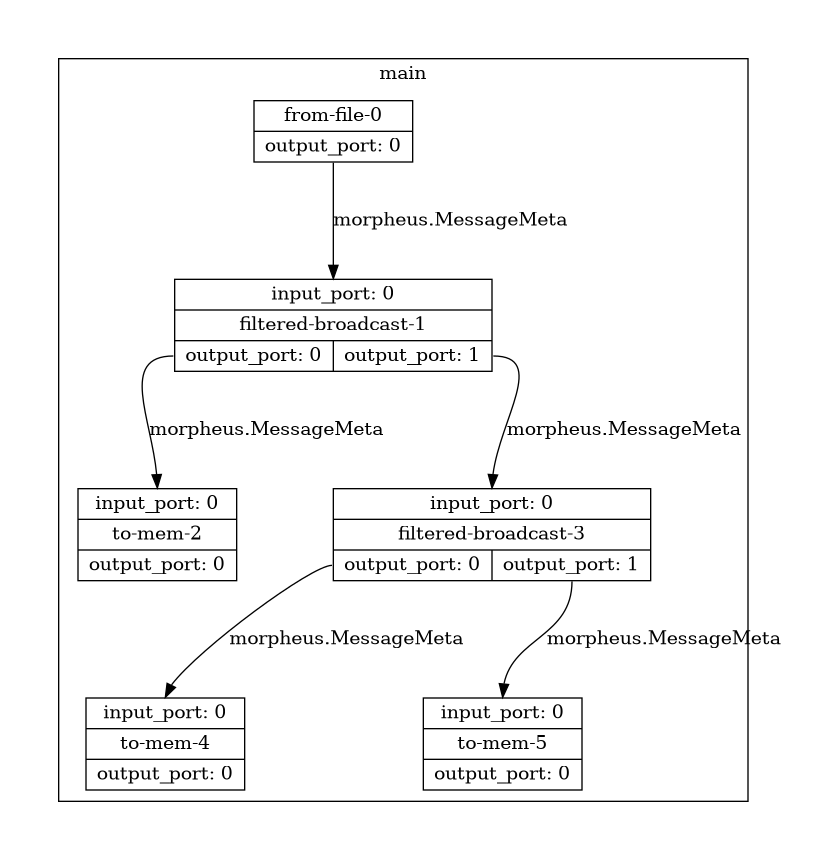

In [14]:
Image(filename=viz_file)

In [15]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: main====
Added source: <from-file-0; FileSourceStage(filename=data/pcap_dump.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <to-mem-2; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-4; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-5; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [16]:
await pipeline.run_async()

In [17]:
large_packets = large_packet_sink.get_messages()
large_packets[0].get_data()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
9465,1617811900142272,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,51450,24
42718,1617815500142642,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,9850,24
75962,1617819100141774,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,31754,24
109387,1617822700142506,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,52970,24
138351,1617825845499898,10.100.8.98,1211,"{""id"":null,""method"":""mining.set_difficulty"",""p...",02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,145.239.0.106,10.100.8.98,2999,29298,24
142596,1617826300142570,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,9960,24
175853,1617829900143095,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,33808,24
191856,1617831648525427,10.100.8.98,1582,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,56476,24
191976,1617831663574010,10.100.8.98,1582,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,49027,24
209017,1617833500142212,10.100.8.98,1615,HTTP/1.0 200 OK\r\nAccept-Ranges: bytes\r\nCon...,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,169.254.169.254,10.100.8.98,80,55418,24


In [18]:
aws_metadata_requests = aws_metadata_sink.get_messages()
aws_metadata_requests[0].get_data()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
5,1617810893919904,10.100.8.98,66,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,2
7,1617810893920071,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,16
8,1617810893920189,10.100.8.98,217,GET /latest/meta-data/network/interfaces/macs/...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,24
11,1617810893921281,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,16
13,1617810893921374,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,46548,80,17
...,...,...,...,...,...,...,...,...,...,...,...,...
537215,1617869017189393,10.100.8.98,66,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,18196,80,2
537217,1617869017189485,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,18196,80,16
537218,1617869017189569,10.100.8.98,208,GET /latest/meta-data/public-hostname HTTP/1.1...,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,18196,80,24
537221,1617869017189940,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,169.254.169.254,18196,80,16


In [19]:
all_data = all_data_sink.get_messages()
all_data[0].get_data()

,timestamp,host_ip,data_len,data,src_mac,dest_mac,protocol,src_ip,dest_ip,src_port,dest_port,flags
0,1617810893485061,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28782,6443,16
1,1617810893525610,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,28782,16
2,1617810893640893,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,17
3,1617810893682471,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,69.192.193.45,10.100.8.98,80,49192,17
4,1617810893682486,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,69.192.193.45,49192,80,16
...,...,...,...,...,...,...,...,...,...,...,...,...
537236,1617869019150167,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28762,6443,16
537237,1617869020210012,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,28762,6443,16
537238,1617869021104938,10.100.8.98,54,,02:96:ee:cd:1d:62,02:a6:fc:e6:4d:14,6,10.100.8.98,10.100.1.237,40377,6443,16
537239,1617869021105132,10.100.8.98,54,,02:a6:fc:e6:4d:14,02:96:ee:cd:1d:62,6,10.100.1.237,10.100.8.98,6443,40377,16


---

## Solution

In [ ]:
config = Config()
pipeline = Pipeline(config)

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False))

large_packet_filter = pipeline.add_stage(
    FilteredBroadcastStage(config, filter_large_packets, {"threshold": 1000})
)

pipeline.add_edge(source, large_packet_filter)


large_packet_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(large_packet_filter.output_ports[0], large_packet_sink)


aws_metadata_filter = pipeline.add_stage(
    FilteredBroadcastStage(config, filter_aws_metadata_requests)
)
pipeline.add_edge(large_packet_filter.output_ports[1], aws_metadata_filter)


aws_metadata_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(aws_metadata_filter.output_ports[0], aws_metadata_sink)


all_data_sink = pipeline.add_stage(InMemorySinkStage(config))
pipeline.add_edge(aws_metadata_filter.output_ports[1], all_data_sink)

In [ ]:
pipeline.build()

In [ ]:
viz_file = './pipeline_visualizations/pcap_multi_filter.png'
pipeline.visualize(viz_file)

In [ ]:
Image(filename=viz_file)

In [ ]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

In [ ]:
await pipeline.run_async()

In [ ]:
large_packets = large_packet_sink.get_messages()
large_packets[0].get_data()

In [ ]:
aws_metadata_requests = aws_metadata_sink.get_messages()
aws_metadata_requests[0].get_data()

In [ ]:
all_data = all_data_sink.get_messages()
all_data[0].get_data()